# [2주차] [5. ML] 과제
- **과제 목적**: Titanic 데이터 하나로 처음부터 ML의 과정을 끝까지 직접 밟아봅니다. 라이브러리 함수를 호출하는 데서 끝내지 않고, 학습의 핵심(loss, gradient descent)과 평가의 핵심(confusion matrix와 4대 지표)을 **손으로 직접 계산**해 개념을 체화합니다. 이어서 두 모델을 동일 조건에서 비교하고 성능 차이의 원인을 모델 구조 관점에서 해석합니다. 마지막 심화에서는 수업에서 그림으로만 본 overfitting을 실험으로 직접 재현합니다.

> ⚠️ **주의**: LLM를 써도 좋지만, **판단·검증·해석은 반드시 직접** 수행하고 사용 내역을 `## 3`에 기록하세요.


## 0. 환경 설정

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = 123  # TODO: 랜덤한 숫자 (42 -> 123)
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → `survived`
- 이 데이터에는 label이 (**있다** / ~~없다~~). 따라서 학습 방식은 `지도`학습이다.
- target이 (~~연속형~~ / **범주형**) 이므로, 이 문제는 (~~회귀~~ / **분류**) 문제다. → 정답: `범주형, 분류`
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: `학습 과정에서 모든 데이터의 정답을 외워버리는 과적합을 방지하고 모델이 처음 보는 데이터에 얼마나 잘 대응하는지에 대한 일반화 성능을 평가하기 위해서이다.`


### 1-2. 전처리와 데이터 분할

아래 TODO를 채우고, **각 주석의 빈칸에 '왜 이 단계가 필요한지'를 직접 적으세요.


In [9]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함): 평균을 사용할 경우 이상치에 영향을 받아 대표값이 크게 변할 수 있으므로, 이상치의 영향을 적게 받는 중앙값으로 결측치를 채운다.
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명): 모델 입장에서 문자열 형태의 데이터를 처리하기 힘들기 때문에 여성과 남성을 각각 1과 0의 이진 숫자로 변환한다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유: train/test split 시 클래스(target label) 비율을 비슷하게 유지하기 위해서이다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= MY_SEED,
    stratify= y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

train: (712, 4), test: (179, 4)
train 생존율: 0.383, test 생존율: 0.385


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | 2, 4, 6 | 약 -18.667 | 1.867 |
| 2 | 1.867 | 약 0.133, 약 0.267, 약 0.400 | 약 -1.244 | 1.991 |
| 3 | 1.991 | 약 0.009, 약 0.018, 약 0.027  | 약 -0.084 |  1.999 |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → `매 반복마다 grdient의 크기가 줄어드는 방향으로 변했으며, gradient의 크기가 작아질수록 w의 이동량도 큰 폭에서 작은 폭으로 감소했다. 또한 gradient가 음수이기 때문에 w는 +방향으로 증가했다. 이 과정을 반복하여 gradient가 0에 가까워지면 w의 이동량도 0에 가까워지며 loss가 최소가 되는 지점에 도달하면 학습이 멈추게 된다.`


In [4]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])

w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    grad = -2/len(gx) * np.sum(gx * (gy -w*gx))   # 힌트: -2/len(gx) * np.sum(...)

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유: (아래에 답)
    #경사하강법은 L(w)가 최소가 되는 지점(gradient=0)을 찾기 때문에 gradient의 반대 방향으로 w가 이동해야 한다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")

# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요:
# 손계산에서는 소수 세번째 자리에서 반올림하여 계산했기 때문에 약간의 차이는 발생할 수 있으나 대체로 일치하는 결과가 나왔다.
# 또한 손계산에서는 현재 w를 기준으로 각 데이터의 오차와 gradient를 계산한 후 w를 갱신했지만, 코드에서는 w를 먼저 갱신하므로 loss 계산에서 차이가 발생했을 것으로 생각한다.

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


### 1-4. 두 모델 학습과 비교

수업에서 "모든 알고리즘은 (f의 형태 / loss / 찾는 방법)에 대한 서로 다른 답"이라고 했습니다. 형태가 전혀 다른 두 모델을 **같은 데이터, 같은 조건**에서 학습시켜 비교합니다.

- **모델 A**: Logistic Regression (선형 + sigmoid)
- **모델 B**: Decision Tree (재귀 분할)


In [10]:
# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state=MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서):
    # train 데이터는 모델이 학습에 사용한 데이터이므로 train 정확도만으로는 모델의 일반화 성능을 판단하기 어렵다. test에서는 처음 본 데이터에 대해 추론하는 것이기 때문에 모델의 일반화 성능을 평가하기 위해 train과 test의 정확도를 각각 확인해야 한다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

Logistic Regression  | train acc: 0.8006 | test acc: 0.7989
Decision Tree        | train acc: 0.9846 | test acc: 0.7263


### 1-5. 평가지표 직접 유도

수업에서 "Confusion Matrix 하나에서 4개 지표가 전부 유도된다"고 했습니다. **sklearn의 지표 함수를 쓰기 전에**, TP/TN/FP/FN으로부터 직접 계산해 봅니다. (모델 A 기준)


In [7]:
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# TODO: 아래 4개 지표를 TP/TN/FP/FN '만으로' 직접 계산하세요 (sklearn 함수 사용 금지)
my_accuracy  = (TP + TN) / (TP + TN + FP + FN)
my_precision = TP / (TP + FP)  # [빈칸] precision의 분모에 들어가는 것과 그 의미: 분모에는 (TP+FP)가 들어가며, Precision은 모델이 양성으로 예측한 전체 데이터 중 실제 양성인 데이터의 비율을 나타낸다.
my_recall    = TP/(TP+FN)   # [빈칸] recall의 분모에 들어가는 것과 그 의미: 분모에는 (TP+FN)가 들어가며, recall은 실제 참인 데이터 중 모델이 참으로 올바르게 예측한 비율을 의미한다.
my_f1        = 2 * (my_precision * my_recall)/(my_precision + my_recall)   # 힌트: precision과 recall의 조화평균

# 검증: sklearn과 비교 (통과하지 못하면 수식을 다시 확인)
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

Confusion Matrix:
 [[94 16]
 [22 47]]
TP=47, TN=94, FP=16, FN=22
✅ 4개 지표 모두 sklearn과 일치


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → `LogisticRegression의 test 정확도는 약 0.788, DecisionTree의 test 정확도는 약 0.810로 측정되었다. 현재 데이터의 feature에는 성별, 좌석 등급 등 생존 여부와 관련이 높은 범주형 변수가 포함되어 있다. 따라서 feature와 target 사이의 관계가 단순한 선형관계로 설명되지 않을 수 있는데, DecisionTree가 이러한 feature들을 조건에 따라 분할하면서 이러한 관계들을 반영할 수 있다. 이러한 이유로 DecisionTree의 정확도가 조금 더 높게 나온 것으로 추측된다.`
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → `LogisticRegression의 경우 train acc은 약 0.799, test acc은 약 0.788이 나왔으며, DecisionTree의 경우 train acc은 약 0.980, test acc은 약 0.810이 나왔다. LogisticRegression의 경우 각 feature와 target 사이의 관계를 선형적으로 결과를 예측한다면, DecisionTree의 경우 특정 조건에 따라 데이터를  반복적으로 분할하며 학습한다. 따라서 DecisionTree의 학습 데이터에 대해 더 복잡한 분할을 만들어 높은 정확도를 얻을 수 있지만 이 과정에서 학습 데이터의 노이즈까지 학습하여 과적합될 수 있다. 따라서 LogisticRegression에 비해 Decision Tree에서는 train acc와 test acc의 차이가 비교적 크게 나타난 것으로 보인다.  `
3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → `MY_SEED를 변경했을 때, DecisionTree의 test acc이 약 0.726으로 이전에 비해 큰 폭으로 떨어졌다.이는 데이터가 다르게 분할되면서 모델의 평가 결과가 달라진 것인데, 이러한 데이터 분할에 따라 성능이 흔들리지 않도록 데이터를 나눠 여러 번 검증하는 방법인 Cross validation을 적용할 수 있다.`
4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → `이전에는 DecisionTree에서의 과적합 발생을 미쳐 생각하지 못했는데 실제로 LogisticRegression의 train/test acc 차이와 DecisionTree에서의 차이를 비교해 보면서 DecisionTree에서 과적합이 발생할 수 있음을 확인했다. 이는 DecisionTree가 조건에 따라 데이터를 세밀하게 분할하는 과정에서 학습 데이터에 지나치게 맞춰졌기 때문에 매우 높은 train acc에 비해 test acc은 낮게 나온 것으로 생각해볼 수 있었다.`


## 2. 심화 과제 (선택)

### 2-1. Overfitting 직접 재현하기

 overfitting/underfitting curve를 **본인 데이터로 직접 그립니다.** Decision Tree의 `max_depth`를 1부터 15까지 바꿔가며 train/test 정확도를 기록하세요.


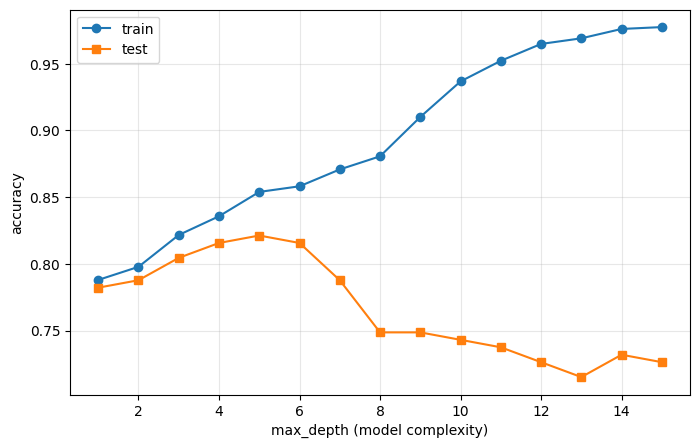

In [11]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    # TODO: max_depth=d인 DecisionTreeClassifier를 학습시키고
    #       train/test 정확도를 각 리스트에 추가하세요
    model = DecisionTreeClassifier(max_depth=d, random_state=MY_SEED)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
# Colab 기본 환경엔 한글 폰트가 없어 제목/라벨은 영문으로 둔다(한글이면 □로 깨짐)
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 해석 (필수):
# - 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가? → underfitting 구간: 1~4, overfitting 구간:6~15
# - 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는? → 최적의 max_depth는 5이며, 해당 지점에서 test 정확도가 가장 높아졌다가 이후부터는 감소하는 모습을 보이기 때문이다.
# - 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가? → 모델의 복잡도가 높아짐에 따라 train acc은 계속해서 증가하지만 test acc은 특정 구간을 지나면 오히려 감소하는 모습을 보인다. 모델의 복잡도를 높이면 학습 데이터에 대해서는 성능을 계속해서 좋게 만들 수 있지만, 새로운 데이터에 대한 일반화 성능까지 좋아지는 것은 아니라는 것을 보여준다. 따라서 train과 test의 성능을 함께 확인하여 과적합 여부를 확인해야 한다.

### 2-2. 비지도학습 미리보기 — label을 가리면 무엇이 보일까?

지금까지는 `survived`라는 label을 알고 학습했습니다(지도학습). 이번엔 **label을 일부러 가리고**, 데이터의 구조만으로 무엇이 보이는지 확인합니다.


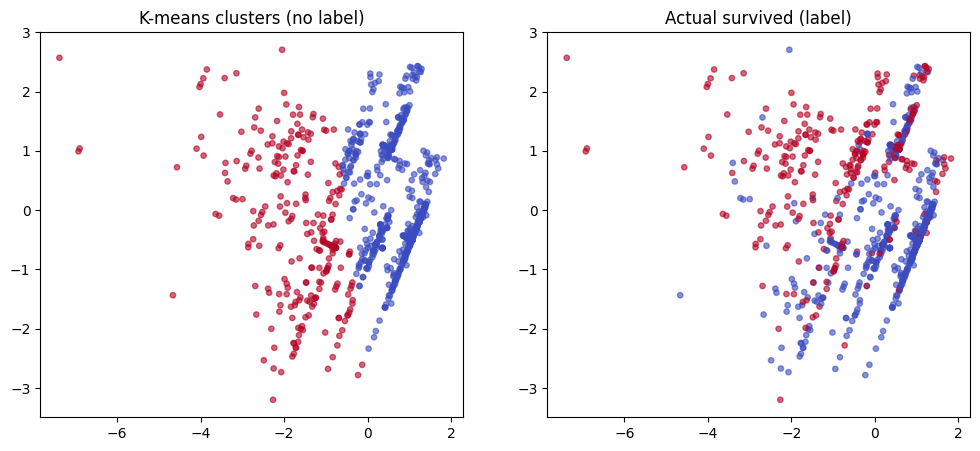

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# [빈칸] PCA/K-means 전에 스케일링이 필요한 이유 (fare와 age의 단위를 생각해 보세요): fare와 age는 단위와 값의 범위에서 큰 차이가 발생하므로 계산 과정에서 큰 영향을 미칠 수 있다. 따라서 먼저 스케일링 과정이 필수적이다.
X_scaled = StandardScaler().fit_transform(X)

# TODO: PCA로 2차원으로 축소하세요
X_2d = PCA(n_components=2).fit_transform(X_scaled)

# TODO: K-means로 2개 군집을 찾으세요 (random_state=MY_SEED, n_init=10)
clusters = KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_2d)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("K-means clusters (no label)")
# ⚠️ c=y 로 넘기면 pandas Series를 단일 RGBA로 오해해 ValueError가 난다. 반드시 c=y.values
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y.values, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Actual survived (label)")
plt.show()

# 해석 (필수):
# - K-means가 찾은 군집은 실제 생존 여부와 얼마나 겹치는가? → K-means가 찾은 군집은 실제 생존 여부와 대부분 겹치지만 실제 생존 여부에는 K-means clustering으로 나눈 군집에 해당하지 않는 값들이 존재한다.
# - 겹친다면/겹치지 않는다면, 그 이유는 무엇이라고 생각하는가?
#   (힌트: K-means는 무엇을 기준으로 데이터를 나누는가?) → K-means는 실제 생존 여부를 기준으로 데이터를 나누는 것이 아니라 k값에 따라 정해진 군집의 중심과 각 데이터 사이의 거리를 기준으로 군집을 판단하기 때문에 실제 생존 여부와 군집이 완전히 일치하지 않을 수 있다.

## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → `2-1에서 코드 작성 후 조건에 맞게 작성했는지 확인하기 위해 사용하였다.`
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `2-1 코드 초안 점검을 제외하고 나머지 항목들은 구글링을 통해 답변을 수정하거나 보충하였다.`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
depths = range(1, 16) train_scores, test_scores = [], [] for d in depths:     # TODO: max_depth=d인 DecisionTreeClassifier를 학습시키고     #       train/test 정확도를 각 리스트에 추가하세요     model = DecisionTreeClassifier(random_state=MY_SEED)     model.fit(X_train, y_train)     train_scores.append(accuracy_score(y_train, model.predict(X_train)))     test_scores.append(accuracy_score(y_test, model.predict(X_test))) 지금 내가 작성한 코드가 맞는지 확인해줄래?

거의 맞는데 한 줄이 빠졌어!
지금 depths = range(1, 16)으로 depth를 1부터 15까지 바꿔가며 실험해야 하는데, 모델 생성 부분에서 max_depth=d를 지정하지 않았어.

현재:

for d in depths:
    model = DecisionTreeClassifier(random_state=MY_SEED)

이러면 매 반복마다 똑같은 Decision Tree를 학습시키게 돼.

따라서 이렇게 해야 해:

depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=MY_SEED
    )
    model.fit(X_train, y_train)

    train_scores.append(
        accuracy_score(y_train, model.predict(X_train))
    )
    test_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

핵심은 이것:

max_depth=d
왜 d를 넣어야 하냐면
depths = range(1, 16)이니까 반복하면서

d = 1
d = 2
d = 3
...
d = 15

가 되잖아. 그러면 각각

DecisionTreeClassifier(max_depth=1)
DecisionTreeClassifier(max_depth=2)
DecisionTreeClassifier(max_depth=3)
...
DecisionTreeClassifier(max_depth=15)를 만들어서 depth에 따른 train/test accuracy 변화를 보는 실험이야. 따라서 네 코드에서 max_depth=d만 추가하면 나머지는 맞아. 👍
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → `크게 어려웠던 부분은 없었지만, K-means clustering 결과가 실제 생존 여부와 다른 이유를 작성하는 과정에서 K-means clustering의 원리가 다른 분류 모델과 헷갈려 관련 내용을 다시 찾아보며 답변을 작성하였다.`
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → `DecisionTree의 과적합 문제와 이를 개선할 수 있는 학습 방식(RandomForest, Gradient Boosting 등)`
